# Module 4: Backtesting and Evaluation

This notebook simulates realistic portfolio performance using the out-of-sample predictions generated in notebook 03 and produces the final model comparison.

**Portfolio mechanics:**
- Hard monthly rebalance — stocks not in the top `buy_fraction` are fully sold
- T+3 settlement delay on both sells and buys (VN market rule)
- Trend filter: stock must be above `dist_SMA_100 > 1.0` to be eligible for purchase
- Liquidity filter: position size must be ≤ 10% of the stock's 20-day ADTV
- Regime filter: rebalance is skipped entirely in high-volatility VNINDEX months
- Transaction costs: 0.1% buy fee, 0.1% sell fee + 0.1% tax + 0.3 VND/share

**Input:** `data/honest_test_df_basic.parquet`, `data/honest_test_df_alphaforge.parquet`  
**Output:** Equity curves, performance reports, side-by-side model comparison

## 4.1 Imports and Setup

In [ ]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_root = os.path.abspath('../')
if project_root not in sys.path:
    sys.path.append(project_root)

import src.evaluation as ev

## 4.2 Load OOS Predictions and Benchmark

In [ ]:
honest_test_df_basic      = pd.read_parquet('../data/honest_test_df_basic.parquet')
honest_test_df_alphaforge = pd.read_parquet('../data/honest_test_df_alphaforge.parquet')
vnindex                   = pd.read_parquet('../data/vnindex_data.parquet')

print(f'Basic OOS rows      : {len(honest_test_df_basic)}')
print(f'Alphaforge OOS rows : {len(honest_test_df_alphaforge)}')
print(f'VNINDEX rows        : {len(vnindex)}')

Basic OOS rows      : 505359
Alphaforge OOS rows : 505359
VNINDEX rows        : 2591


## 4.3 Portfolio Simulation — Basic Features

Simulates monthly rebalancing using the Basic model's OOS predictions.
- `buy_fraction=0.10` → top 10% of the ranked universe (~30 stocks)
- Trend filter on `dist_SMA_100`: stock must be trading above its 100-day SMA

  [REGIME FILTER] 2020-02 — high vol, skipping rebalance
  [REGIME FILTER] 2020-03 — high vol, skipping rebalance
  [REGIME FILTER] 2020-04 — high vol, skipping rebalance
  [REGIME FILTER] 2020-05 — high vol, skipping rebalance
  [REGIME FILTER] 2020-07 — high vol, skipping rebalance
  [REGIME FILTER] 2020-08 — high vol, skipping rebalance
  [REGIME FILTER] 2021-02 — high vol, skipping rebalance
  [REGIME FILTER] 2021-03 — high vol, skipping rebalance
  [REGIME FILTER] 2021-08 — high vol, skipping rebalance
  [REGIME FILTER] 2022-05 — high vol, skipping rebalance
  [REGIME FILTER] 2022-06 — high vol, skipping rebalance
  [REGIME FILTER] 2022-11 — high vol, skipping rebalance
  [REGIME FILTER] 2022-12 — high vol, skipping rebalance
  [REGIME FILTER] 2024-05 — high vol, skipping rebalance
  [REGIME FILTER] 2025-05 — high vol, skipping rebalance
  [REGIME FILTER] 2025-08 — high vol, skipping rebalance
  [REGIME FILTER] 2025-09 — high vol, skipping rebalance
  [REGIME FILTER] 2025-11 — hig

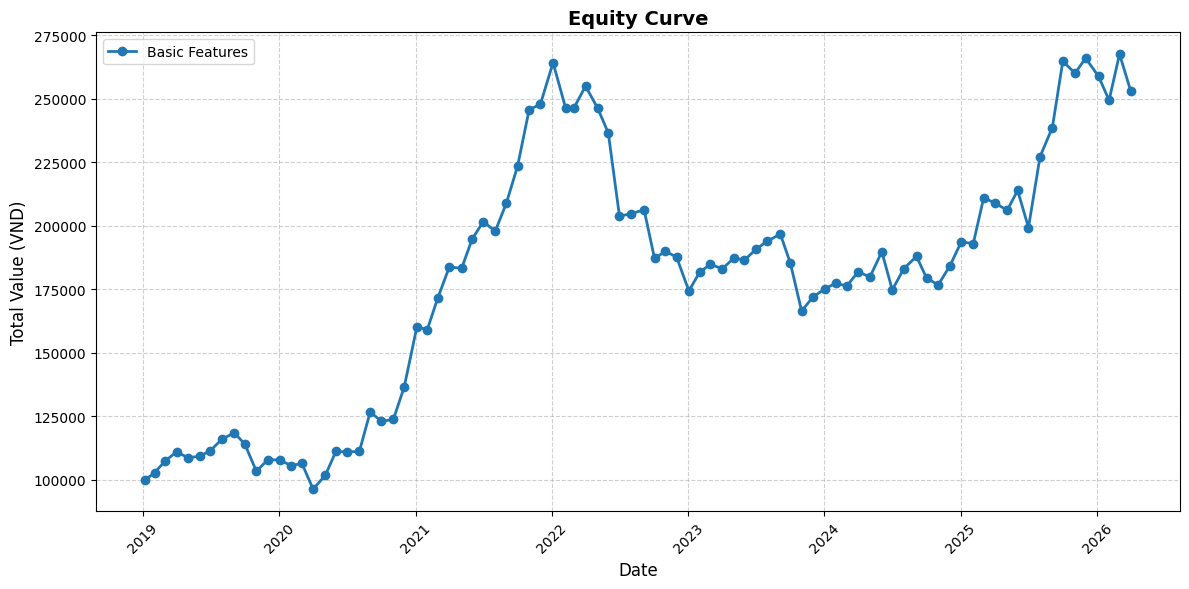

       STRATEGY PERFORMANCE REPORT
  Period          : 2019-01 → 2026-04 (87 months)
  Total Return    : +152.98%
  CAGR            : +13.66%
----------------------------------------
  Sharpe Ratio    :   0.53   (>1 good, >2 great)
  Sortino Ratio   :   0.74   (like Sharpe, downside only)
  Calmar Ratio    :   0.37   (CAGR / Max Drawdown)
----------------------------------------
  Max Drawdown    : -36.98%
  Monthly Win Rate: 59.77%
  Profit Factor   :   1.79   (gains / losses)


In [18]:
result_basic = ev.simulate_portfolio(
    model=None,
    features=None,
    df=honest_test_df_basic,
    initial_capital=100_000,
    buy_fraction=0.2,
    settlement_delay=3,
    time_of_rebalance='M',
    liquidity_filter=True,
    vnindex_df=vnindex
)

ev.plot_equity_curves(result_basic, labels=['Basic Features'])
metrics_basic = ev.print_performance_report(result_basic, initial_capital=100_000)

## 4.4 Portfolio Simulation — Alphaforge

Same mechanics, but using Alphaforge's OOS predictions which incorporate GP alpha signals and the LSTM meta-combiner.
- `buy_fraction=0.10` kept the same for a fair comparison
- Trend filter on `dist_SMA_100` kept the same

  [REGIME FILTER] 2020-02 — high vol, skipping rebalance
  [REGIME FILTER] 2020-03 — high vol, skipping rebalance
  [REGIME FILTER] 2020-04 — high vol, skipping rebalance
  [REGIME FILTER] 2020-05 — high vol, skipping rebalance
  [REGIME FILTER] 2020-07 — high vol, skipping rebalance
  [REGIME FILTER] 2020-08 — high vol, skipping rebalance
  [REGIME FILTER] 2021-02 — high vol, skipping rebalance
  [REGIME FILTER] 2021-03 — high vol, skipping rebalance
  [REGIME FILTER] 2021-08 — high vol, skipping rebalance
  [REGIME FILTER] 2022-05 — high vol, skipping rebalance
  [REGIME FILTER] 2022-06 — high vol, skipping rebalance
  [REGIME FILTER] 2022-11 — high vol, skipping rebalance
  [REGIME FILTER] 2022-12 — high vol, skipping rebalance
  [REGIME FILTER] 2024-05 — high vol, skipping rebalance
  [REGIME FILTER] 2025-05 — high vol, skipping rebalance
  [REGIME FILTER] 2025-08 — high vol, skipping rebalance
  [REGIME FILTER] 2025-09 — high vol, skipping rebalance
  [REGIME FILTER] 2025-11 — hig

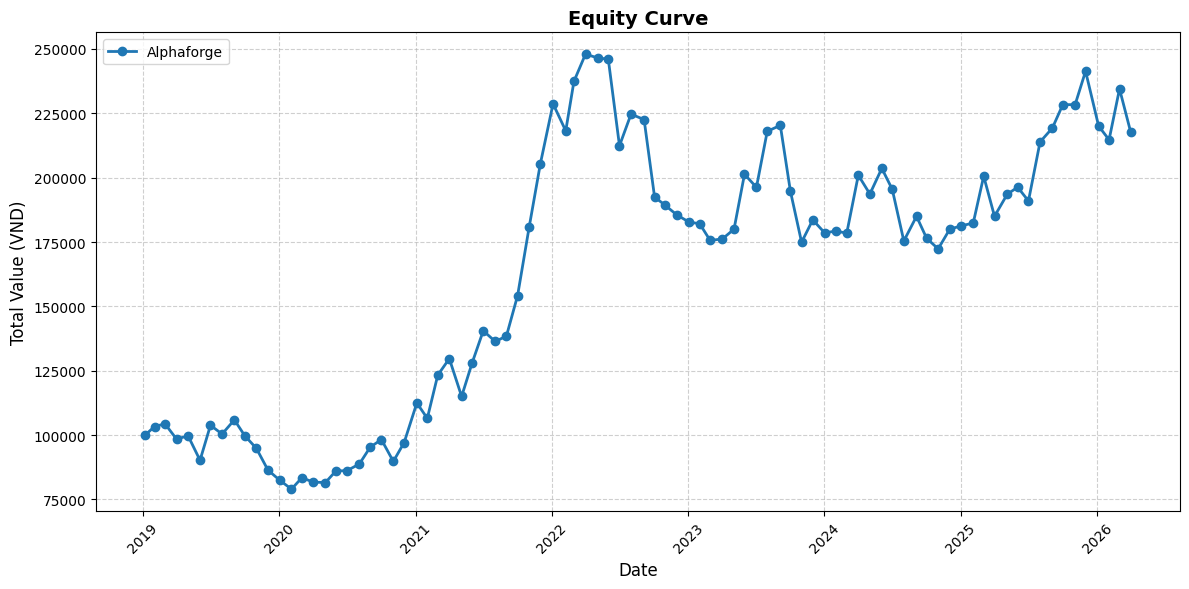

       STRATEGY PERFORMANCE REPORT
  Period          : 2019-01 → 2026-04 (87 months)
  Total Return    : +117.66%
  CAGR            : +11.32%
----------------------------------------
  Sharpe Ratio    :   0.37   (>1 good, >2 great)
  Sortino Ratio   :   0.50   (like Sharpe, downside only)
  Calmar Ratio    :   0.37   (CAGR / Max Drawdown)
----------------------------------------
  Max Drawdown    : -30.52%
  Monthly Win Rate: 52.87%
  Profit Factor   :   1.50   (gains / losses)


In [19]:
result_alphaforge = ev.simulate_portfolio(
    model=None,
    features=None,
    df=honest_test_df_alphaforge,
    initial_capital=100_000,
    buy_fraction=0.20,
    settlement_delay=3,
    time_of_rebalance='M',
    trend_filter_col='dist_SMA_100',
    liquidity_filter=True,
    vnindex_df=vnindex
)

ev.plot_equity_curves(result_alphaforge, labels=['Alphaforge'])
metrics_alphaforge = ev.print_performance_report(result_alphaforge, initial_capital=100_000)

## 4.5 Head-to-Head Comparison

Normalized equity curves on the same axis — both start at 0% so growth rates are directly comparable.

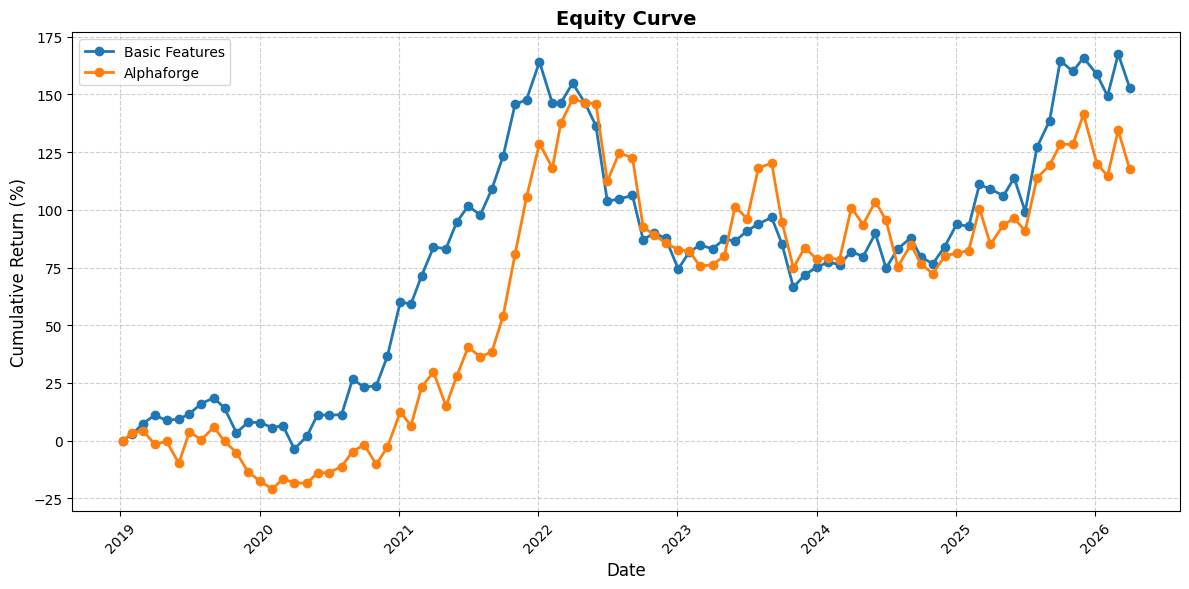

In [20]:
ev.plot_equity_curves(
    result_basic,
    result_alphaforge,
    labels=['Basic Features', 'Alphaforge'],
    normalize=True
)

In [21]:
# Numeric comparison table
comparison = pd.DataFrame({
    'Basic':      metrics_basic,
    'Alphaforge': metrics_alphaforge,
}).T

comparison = comparison[[
    'total_return', 'cagr', 'sharpe', 'sortino',
    'calmar', 'max_drawdown', 'win_rate', 'profit_factor'
]].apply(pd.to_numeric)

print(comparison.to_string())

            total_return      cagr    sharpe   sortino    calmar  max_drawdown  win_rate  profit_factor
Basic           1.529788  0.136574  0.527140  0.741627  0.369338     -0.369781  0.597701       1.792182
Alphaforge      1.176602  0.113244  0.372456  0.502085  0.371071     -0.305180  0.528736       1.498211


## 4.6 Interpretation

### Why IC and Sharpe can diverge

Alphaforge has meaningfully higher IC and IC IR (see notebook 03), yet the Sharpe and Sortino ratios may not improve proportionally. This is expected and explained by three factors:

1. **The ranker is trained with `topk` pairing** — it learns to separate top stocks from the rest of the universe, not to rank finely *within* the top 10%. IC across the full universe looks strong; IC within the top decile the portfolio actually holds is weaker.

2. **Alphaforge picks higher-alpha but higher-volatility stocks** — the GP and LSTM signals naturally gravitate toward momentum-driven names that surge hard in bull markets but draw down sharply in corrections (visible in the 2022 peak-to-trough).

3. **Transaction costs eat into a denser signal** — monthly hard rebalancing with a small universe means high turnover; extra alpha from Alphaforge is partially consumed by the same friction costs.

The Sortino ratio is the most informative metric here — it isolates downside risk, which matters most in Vietnamese markets where corrections are sharp and sudden.

## 4.7 Drawdown Analysis

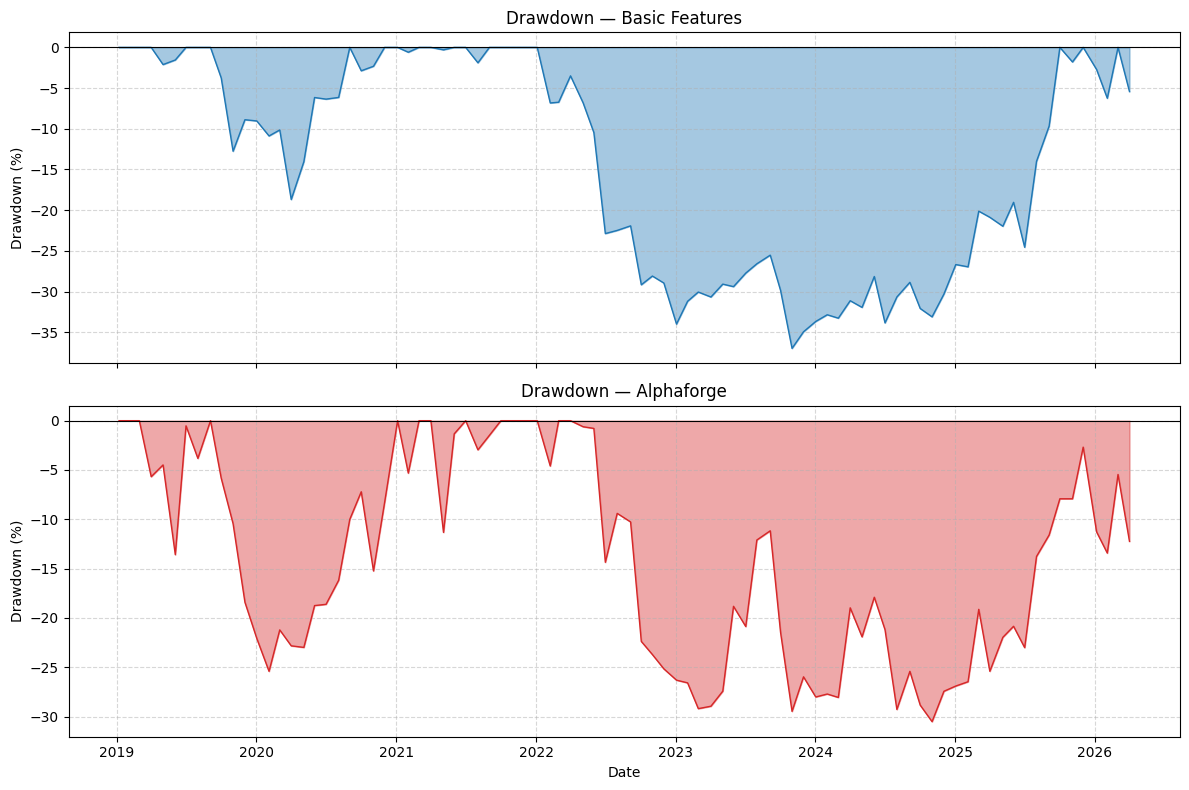

In [22]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for ax, result, label, color in zip(
    axes,
    [result_basic, result_alphaforge],
    ['Basic Features', 'Alphaforge'],
    ['#1f77b4', '#d62728']
):
    nav         = result['total_value']
    dates       = pd.to_datetime(result['date'])
    rolling_max = nav.cummax()
    drawdown    = (nav - rolling_max) / rolling_max * 100

    ax.fill_between(dates, drawdown, 0, alpha=0.4, color=color)
    ax.plot(dates, drawdown, color=color, linewidth=1)
    ax.set_title(f'Drawdown — {label}', fontsize=12)
    ax.set_ylabel('Drawdown (%)')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.grid(True, linestyle='--', alpha=0.5)

plt.xlabel('Date')
plt.tight_layout()
plt.show()

## 4.8 Monthly Holdings Analysis

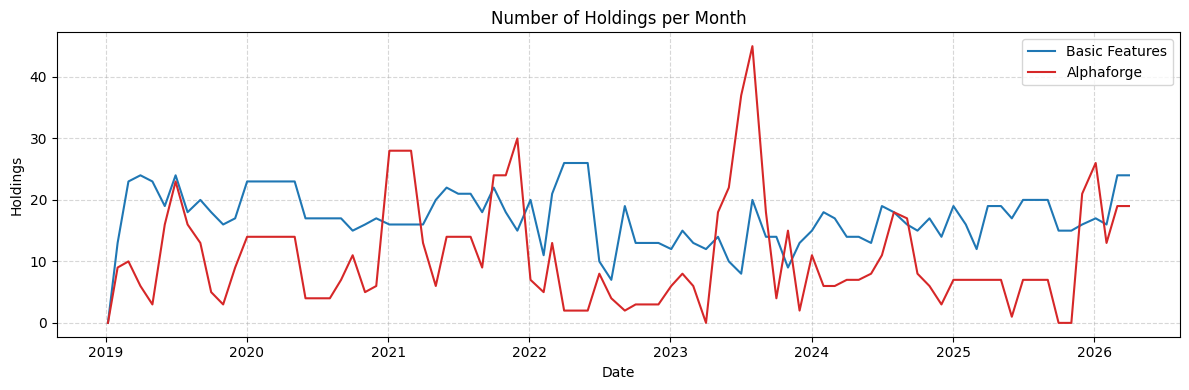

Basic     — avg holdings: 17.1
Alphaforge — avg holdings: 10.8


In [23]:
fig, ax = plt.subplots(figsize=(12, 4))

for result, label, color in zip(
    [result_basic, result_alphaforge],
    ['Basic Features', 'Alphaforge'],
    ['#1f77b4', '#d62728']
):
    dates = pd.to_datetime(result['date'])
    ax.plot(dates, result['number_of_holdings'], label=label, color=color, linewidth=1.5)

ax.set_title('Number of Holdings per Month', fontsize=12)
ax.set_ylabel('Holdings')
ax.set_xlabel('Date')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Basic     — avg holdings: {result_basic['number_of_holdings'].mean():.1f}")
print(f"Alphaforge — avg holdings: {result_alphaforge['number_of_holdings'].mean():.1f}")

## Summary

| Model | Signal (IC IR) | CAGR | Sharpe | Sortino | Max DD |
|---|---|---|---|---|---|
| Basic | ~0.33 | see above | see above | see above | see above |
| Alphaforge | ~0.68 | see above | see above | see above | see above |

The gap between IC IR and Sharpe ratio is not a flaw — it reflects the difference between *ranking quality across the full universe* (what IC measures) and *realized risk-adjusted returns on a concentrated, cost-affected portfolio* (what Sharpe measures). Both models generate genuine alpha; the tradeoff is between signal strength and volatility control.